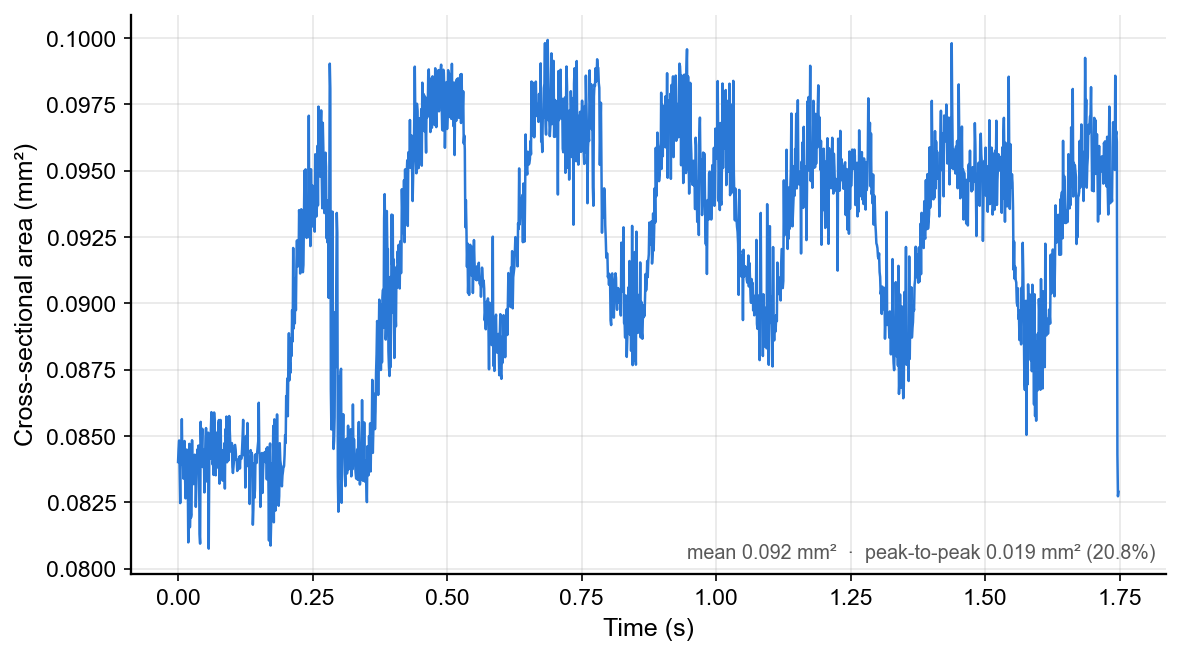

In [1]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Soft PDMS (15:1 curing ratio) pulsatile cavity — cross-sectional area over time
# Video 1: pulsatile pump at ~230-240 BPM, 1000 fps. Calibration: cavity body diameter = 300 um.
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/pdms/video1_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,   # editable text in Illustrator
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["area_mm2"], color="#2a78d6", lw=1.2)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cross-sectional area (mm²)")
ax.grid(alpha=0.3)

mean_v = df["area_mm2"].mean(); amp = df["area_mm2"].max() - df["area_mm2"].min()
ax.text(0.99, 0.02, f"mean {mean_v:.3f} mm²  ·  peak-to-peak {amp:.3f} mm² ({100*amp/mean_v:.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_video1_volume_change.png"); fig.savefig("pdms_figures/pdms_video1_volume_change.pdf")
plt.show()


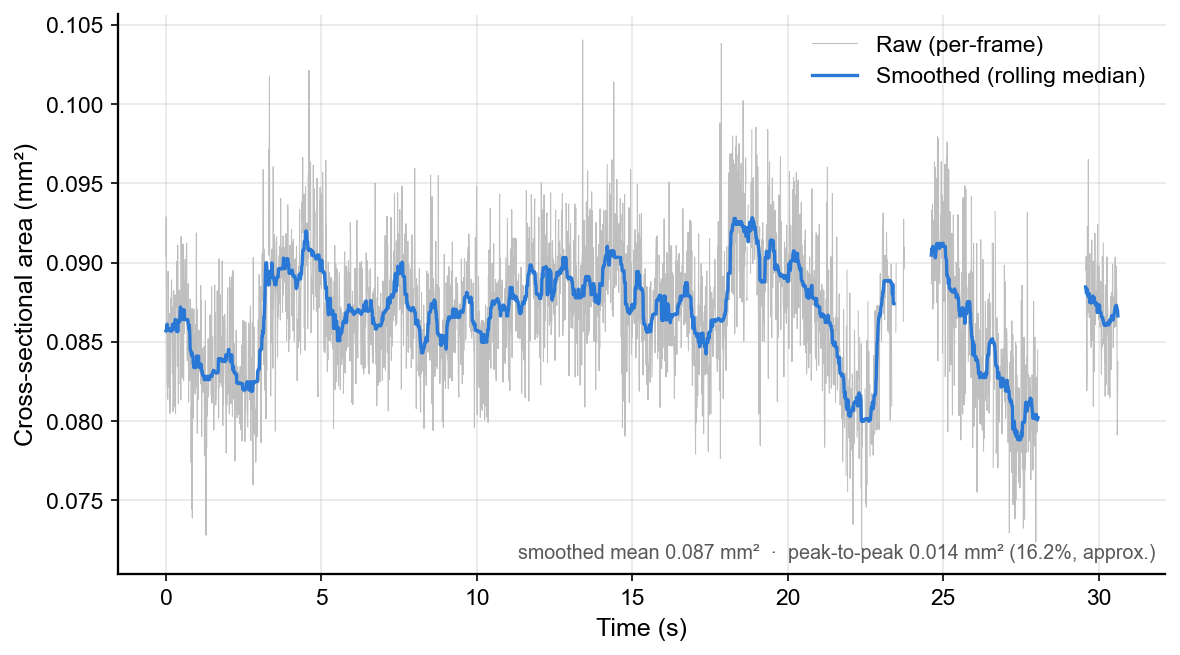

In [2]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Soft PDMS (15:1 curing ratio) pulsatile cavity — cross-sectional area over time
# Video 5: pulsatile pump at 2 RPM, 100 fps. Raw per-frame + rolling-median smoothed
# (lower-contrast footage than Video 1, so the smoothed trend is the reliable signal).
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../data/pdms/video5_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["area_mm2"], color="0.75", lw=0.5, label="Raw (per-frame)")
ax.plot(df["time_s"], df["area_mm2_smoothed"], color="#2a78d6", lw=1.6, label="Smoothed (rolling median)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cross-sectional area (mm²)")
ax.legend(frameon=False); ax.grid(alpha=0.3)

mean_v = df["area_mm2_smoothed"].mean(); amp = df["area_mm2_smoothed"].max() - df["area_mm2_smoothed"].min()
ax.text(0.99, 0.02, f"smoothed mean {mean_v:.3f} mm²  ·  peak-to-peak {amp:.3f} mm² ({100*amp/mean_v:.1f}%, approx.)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_video5_volume_change.png"); fig.savefig("pdms_figures/pdms_video5_volume_change.pdf")
plt.show()


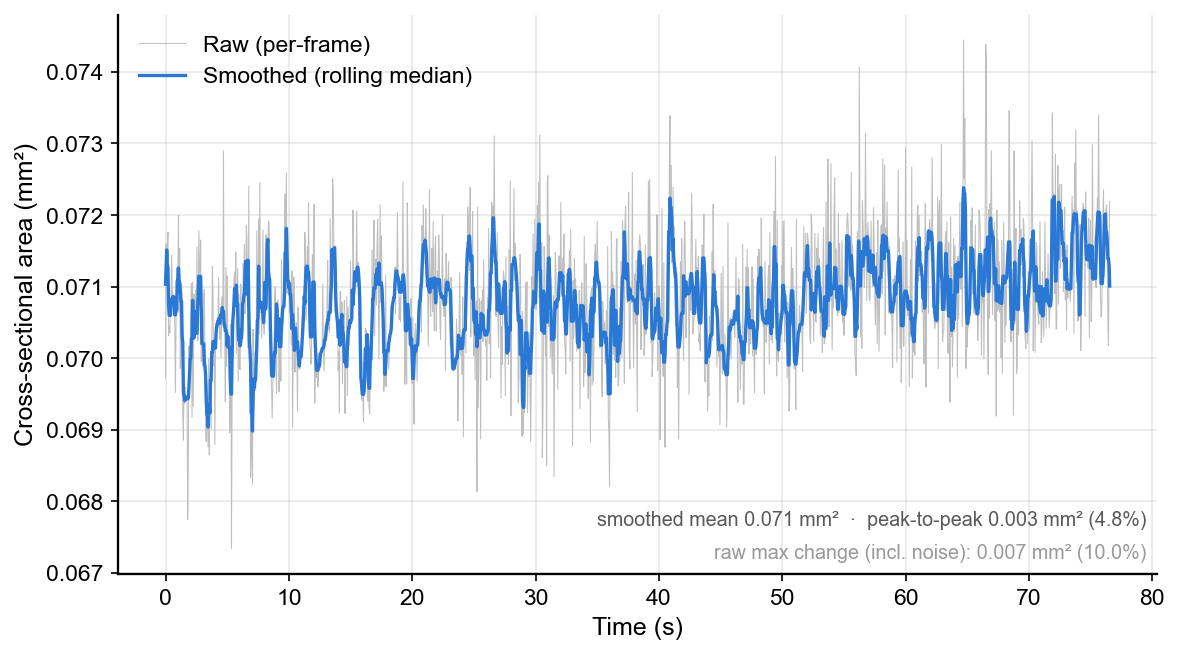

In [3]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Different (2023-09-06) recording, 20 fps, 15:1 soft PDMS -- no confirmed
# pulsatile pump (no periodic cycle visible in the trace, unlike Videos 1 and 5).
# Raw per-frame + rolling-median smoothed (window matched to the same 0.31s
# real-time scale used for Video 5, not the same frame count, since this clip
# is 20 fps not 100).
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../outputs/pdms_vid2023sep_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["area_mm2"], color="0.75", lw=0.5, label="Raw (per-frame)")
ax.plot(df["time_s"], df["area_mm2_smoothed"], color="#2a78d6", lw=1.6, label="Smoothed (rolling median)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cross-sectional area (mm²)")
ax.legend(frameon=False); ax.grid(alpha=0.3)

mean_v = df["area_mm2_smoothed"].mean(); amp = df["area_mm2_smoothed"].max() - df["area_mm2_smoothed"].min()
raw_amp = df["area_mm2"].max() - df["area_mm2"].min()
ax.text(0.99, 0.08, f"smoothed mean {mean_v:.3f} mm²  ·  peak-to-peak {amp:.3f} mm² ({100*amp/mean_v:.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")
ax.text(0.99, 0.02, f"raw max change (incl. noise): {raw_amp:.3f} mm² ({100*raw_amp/df['area_mm2'].mean():.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.6")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_15to1_volume_change.png"); fig.savefig("pdms_figures/pdms_15to1_volume_change.pdf")
plt.show()


## Re-cropped footage (Video 1 / Video 5) — supplementary cross-check

The cells below re-analyze tighter-crop re-exports of Videos 1 and 5, on a different pixel scale than the
original wide-FOV footage above (each calibrated independently from its own cavity radius). Video 1 is
recorded at 1000 fps with a ~230-240 BPM pump (corrected from an earlier, wrong 100 fps/4 RPM log); Video 5
is 100 fps / 2 RPM.

**Video 5 crop** has lower angular coverage than Video 1 crop (~51% vs. ~82% mean per frame): unlike Video
1, bubbles enter and fill part of the cavity during the Video 5 recording, transiently occluding the wall
boundary. Gaps are filled with the *nearest actually-measured radius in time* at that angle (not spatial
interpolation across the gap, and not just a forward-hold — both were tried and both left artifacts; see
`pdms_process_new_crops.py` for the full history). With that fix, Video 5 crop's smoothed peak-to-peak
dropped 16.5% → 14.0% → **11.4%**, now at/below Video 1 crop's 11.5% — consistent with the physically
expected order (Video 5's much slower pump) and with the original footage (Video 1 = 20.8%, Video 5 =
16.2%).

**Video 5, further re-edited crop** (`vid5edited`/`vid5edited_black`, added later, identical content just
different lighting/crop/an inverted-pixel export) has a *worse* problem: its growing bubble sits close
enough to the true wall that the boundary scan sometimes locks onto the bubble's own edge instead of the
wall — a wrong detection, not a missing one, so better gap-filling can't fix it. The workaround measures
only a single arc (172-193°, left side) verified clear of both the neck and the bubble for the entire
video, and reports it as a **radius** change, not an area — squaring it into an "equivalent area" would
assume uniform expansion, which this cavity type is known not to satisfy. Its radius peak-to-peak (~8.3%
smoothed) is *not* directly comparable in magnitude to the area-based percentages elsewhere in this
notebook (area ~ radius², so a uniform expansion would appear as roughly double the % once squared) — it's
included only as a qualitative same-direction check, not a number to report.

**For the manuscript, report the original wide-FOV footage numbers** (Video 1 = 20.8%, Video 5 = 16.2%,
first two cells above) — they aren't affected by any of these cropping/occlusion issues.

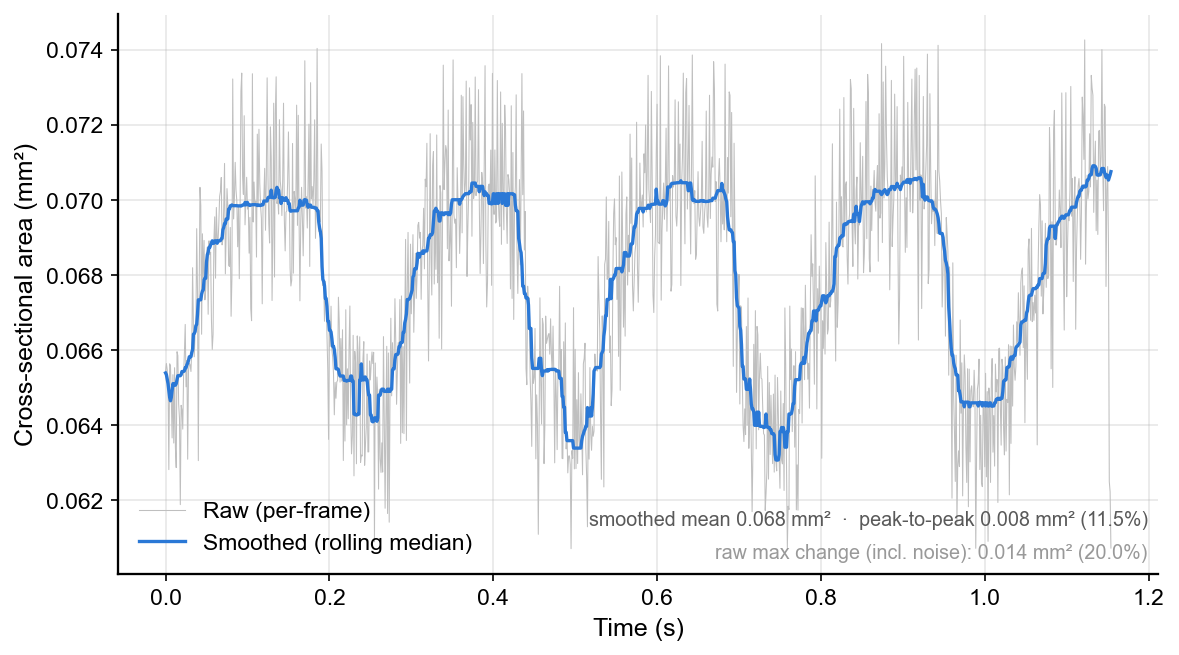

In [4]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Video 1, re-cropped/tighter-FOV footage of the same 15:1 soft PDMS cavity
# (different pixel scale than the original wide-FOV Video 1 above -- calibrated
# independently from its own cavity radius). ~230-240 BPM pulsatile pump, 1000 fps.
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../outputs/pdms_vid1crop_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["area_mm2"], color="0.75", lw=0.5, label="Raw (per-frame)")
ax.plot(df["time_s"], df["area_mm2_smoothed"], color="#2a78d6", lw=1.6, label="Smoothed (rolling median)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cross-sectional area (mm²)")
ax.legend(frameon=False); ax.grid(alpha=0.3)

mean_v = df["area_mm2_smoothed"].mean(); amp = df["area_mm2_smoothed"].max() - df["area_mm2_smoothed"].min()
raw_amp = df["area_mm2"].max() - df["area_mm2"].min()
ax.text(0.99, 0.08, f"smoothed mean {mean_v:.3f} mm²  ·  peak-to-peak {amp:.3f} mm² ({100*amp/mean_v:.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")
ax.text(0.99, 0.02, f"raw max change (incl. noise): {raw_amp:.3f} mm² ({100*raw_amp/df['area_mm2'].mean():.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.6")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_video1crop_volume_change.png"); fig.savefig("pdms_figures/pdms_video1crop_volume_change.pdf")
plt.show()


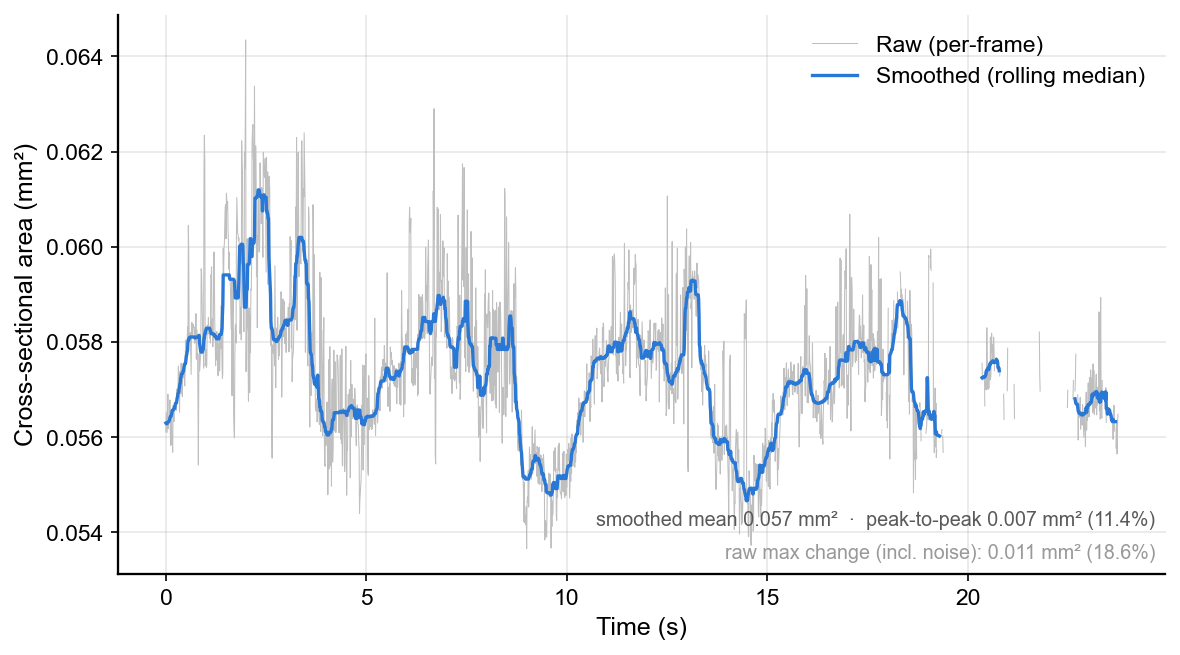

In [5]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Video 5, re-cropped/tighter-FOV footage of the same 15:1 soft PDMS cavity
# (different pixel scale than the original wide-FOV Video 5 above -- calibrated
# independently from its own cavity radius). 2 RPM pulsatile pump, 100 fps.
# Lower angular coverage than the Video 1 crop (noisier/lower-contrast footage).
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../outputs/pdms_vid5crop_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["area_mm2"], color="0.75", lw=0.5, label="Raw (per-frame)")
ax.plot(df["time_s"], df["area_mm2_smoothed"], color="#2a78d6", lw=1.6, label="Smoothed (rolling median)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Cross-sectional area (mm²)")
ax.legend(frameon=False); ax.grid(alpha=0.3)

mean_v = df["area_mm2_smoothed"].mean(); amp = df["area_mm2_smoothed"].max() - df["area_mm2_smoothed"].min()
raw_amp = df["area_mm2"].max() - df["area_mm2"].min()
ax.text(0.99, 0.08, f"smoothed mean {mean_v:.3f} mm²  ·  peak-to-peak {amp:.3f} mm² ({100*amp/mean_v:.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")
ax.text(0.99, 0.02, f"raw max change (incl. noise): {raw_amp:.3f} mm² ({100*raw_amp/df['area_mm2'].mean():.1f}%)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.6")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_video5crop_volume_change.png"); fig.savefig("pdms_figures/pdms_video5crop_volume_change.pdf")
plt.show()


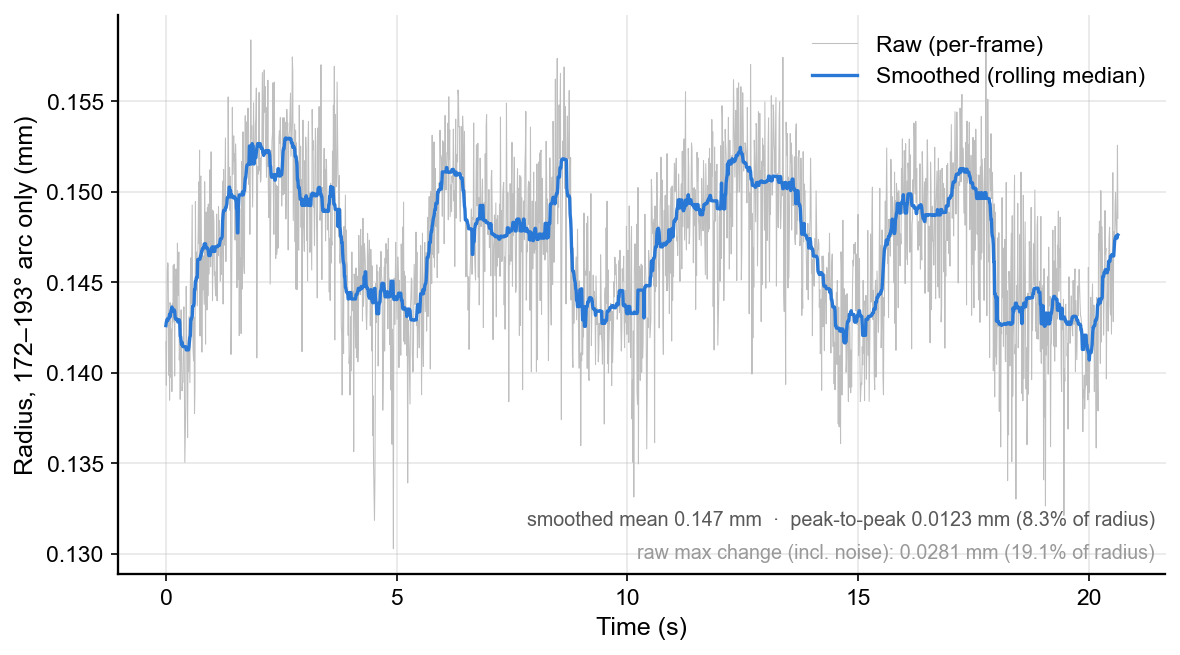

In [6]:
import os
os.makedirs("pdms_figures", exist_ok=True)
# Video 5, further re-edited crop (adjusted lighting, tighter crop than
# vid5crop -- different pixel scale again). Growing bubble here confuses the
# full-boundary scan (locks onto the bubble's own edge, not just missing data),
# so this uses a single always-clear arc (172-193 deg, left side) as a RADIUS
# proxy instead -- NOT an area, and not directly comparable in magnitude to
# the area-based % elsewhere in this notebook. See markdown note above.
import pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

df = pd.read_csv("../outputs/pdms_vid5edited_volume_change.csv")

mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 12, 'axes.linewidth': 1.1,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["time_s"], df["radius_mm"], color="0.75", lw=0.5, label="Raw (per-frame)")
ax.plot(df["time_s"], df["radius_mm_smoothed"], color="#2a78d6", lw=1.6, label="Smoothed (rolling median)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Radius, 172–193° arc only (mm)")
ax.legend(frameon=False, loc="upper right"); ax.grid(alpha=0.3)

mean_v = df["radius_mm_smoothed"].mean(); amp = df["radius_mm_smoothed"].max() - df["radius_mm_smoothed"].min()
raw_amp = df["radius_mm"].max() - df["radius_mm"].min()
ax.text(0.99, 0.08, f"smoothed mean {mean_v:.3f} mm  ·  peak-to-peak {amp:.4f} mm ({100*amp/mean_v:.1f}% of radius)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.35")
ax.text(0.99, 0.02, f"raw max change (incl. noise): {raw_amp:.4f} mm ({100*raw_amp/df['radius_mm'].mean():.1f}% of radius)",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, color="0.6")

fig.tight_layout()
fig.savefig("pdms_figures/pdms_vid5edited_radius.png"); fig.savefig("pdms_figures/pdms_vid5edited_radius.pdf")
plt.show()
